In [288]:
import os
import rootutils
import pandas as pd
import random
import numpy as np

import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
tqdm.pandas()

rootutils.setup_root(os.path.abspath('./'), indicator=".project-root", pythonpath=True, dotenv=True, cwd=True)

# auto-loading of imports from outside scripts
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Melting points:

In [289]:
df_temp = pd.read_csv('data_cod/melting_points.csv')
df_temp = df_temp[df_temp["T"].notna()]
df_temp.to_csv('data_cod/melting_points_filtered.csv', index=False)

In [290]:

def filter_temprature(row):
    if "(" in str(row["T"]):
        temp = str(row["T"]).split("(")[0]
        row["T"] = temp
    
    try:
        row["T"] = float(row["T"]) - 273
        if row["T"] > 900 or row["T"] < -250:
            row["T"] = None
        return row
    except:
        row["T"] = None
        return row

In [291]:
df_temp = df_temp.progress_apply(filter_temprature, axis=1)
df_temp = df_temp[df_temp["T"].notna()]

df_temp.to_csv('data_cod/melting_points_filtered.csv', index=False)

  0%|          | 0/15385 [00:00<?, ?it/s]

---
## Merging with Bradley:

In [312]:
from src.cif_utils import get_canonical_smiles

In [313]:
df_cod = pd.read_csv('data_cod/cod_parsed_canonical.csv')
df_bradley = pd.read_csv('data/Bradley_with_canonical_smiles.csv')

In [314]:
brad_smiles = df_bradley["can_smiles"].tolist()

In [315]:
df_intersect_cod_brad = pd.merge(df_bradley, df_cod, on='can_smiles', how='inner')

In [316]:
df_intersect_cod_brad = df_intersect_cod_brad[["id", "can_smiles", "T"]]

### Adding temperatures from COD:

Text(0.5, 1.0, 'Temperature Distribution Comparison')

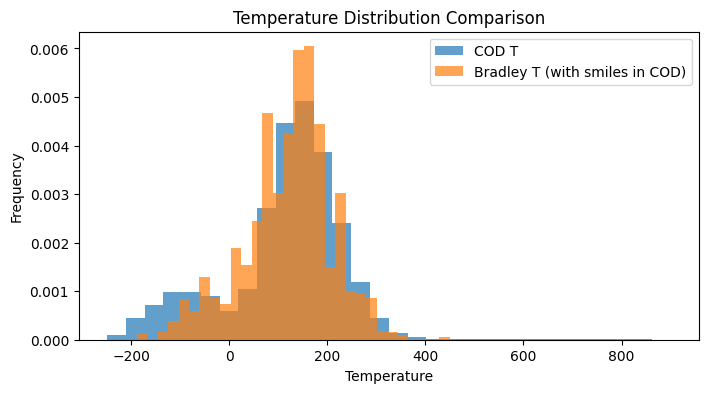

In [334]:
temps_cod = df_temp["T"].tolist()
temps_bradley = df_intersect_cod_brad["T"].tolist()

plt.figure(figsize=(8, 4))
plt.hist(temps_cod, bins=30, alpha=0.7, label='COD T', density=True)
plt.hist(temps_bradley, bins=30, alpha=0.7, label='Bradley T (with smiles in COD)', density=True)
plt.legend()
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Temperature Distribution Comparison')


In [321]:
# Get the COD entries that have temperature data
cod_with_temp = df_cod[df_cod["id"].isin(df_temp["id"])]
# Merge with temperature data
cod_with_temp = pd.merge(cod_with_temp, df_temp[["id", "T"]], on="id", how="left")
cod_with_temp = cod_with_temp[["id", "can_smiles", "T"]]

In [330]:
# From COD remove entries that are present in Bradley:

ids_in_common = set(cod_with_temp['id']) & set(df_intersect_cod_brad['id'])
cod_with_temp = cod_with_temp[~cod_with_temp['id'].isin(ids_in_common)]

In [331]:
df_final = pd.concat([cod_with_temp, df_intersect_cod_brad])

In [332]:
df_final.to_csv('data_cod/cod_bradley_merged.csv', index=False)